# Reading FCS, compensation and display scales

Cytometry is a modality, not a sub-analysis of single-cell RNA-seq. An event is
a cell, but nothing else transfers: the file format is FCS, the values a
detector reports are contaminated by every *other* fluorochrome in the panel,
and the axis you look at is a nonlinear display scale that has to be carried
around with the data or every gate drawn on it becomes meaningless.

`ov.flow` covers those three things, and this notebook is about all three:

1. **reading** — `ov.io.read_fcs`, and what lands in the `AnnData`
2. **compensation** — undoing spillover between detectors
3. **display transforms** — logicle / hyperlog / asinh, and why a log axis is
   not an option

Two later notebooks build on this one: [gating](t_flow_02_gating.ipynb) and
[saving a strategy](t_flow_03_gatingml.ipynb).

## A sample to work on

Everything below runs on a synthetic file this notebook writes itself, so there
is nothing to download. It contains nine known populations, a genuine spillover
matrix in the `$SPILLOVER` keyword, and — importantly — a detector noise floor
that pushes dim events **below zero**. Real data does that, and it is the whole
reason the display scales at the end of this notebook exist.

In [1]:
# The tutorials need no data of your own: this writes a small synthetic FCS 3.1
# file with known populations, a real $SPILLOVER keyword and a realistic noise
# floor (values around zero go negative, which is why a log axis will not do).
# It is written into the CURRENT WORKING DIRECTORY, as is strategy.xml later.
import numpy as np, pathlib, flowio

PANEL   = ["FSC-A","FSC-H","SSC-A","FITC-A","PE-A","PerCP-A","APC-A","Zombie-A"]
MARKERS = [None, None, None, "CD3", "CD4", "CD19", "CD8", "Viability"]
FLUORS  = ["FITC-A","PE-A","PerCP-A","APC-A"]
SPILL   = np.array([[1.00,0.18,0.06,0.01],
                    [0.03,1.00,0.11,0.01],
                    [0.01,0.04,1.00,0.14],
                    [0.00,0.01,0.03,1.00]])

def synthesise(seed=0):
    rng = np.random.default_rng(seed)
    def block(n, fsc, ssc, cd3, cd4, cd19, cd8, via, doublet=False):
        f = rng.normal(fsc, fsc*0.09, n)
        h = f/(1.85 if doublet else 1.0) + rng.normal(0, fsc*0.025, n)
        s = rng.normal(ssc, ssc*0.13, n)
        ch = lambda lv: rng.lognormal(np.log(lv), 0.42 if lv > 300 else 0.85, n)
        return (np.column_stack([f,h,s]),
                np.column_stack([ch(cd3),ch(cd4),ch(cd19),ch(cd8)]), ch(via))
    spec = [("debris",11000,17000,8500,25,22,20,24,55,False),
            ("CD4 T",17000,78000,24000,7500,9500,22,26,60,False),
            ("CD8 T",10000,76000,23000,8000,24,21,7000,58,False),
            ("DN T",1400,74000,22000,6500,26,23,28,62,False),
            ("DP T",500,79000,25000,7200,4200,22,3500,61,False),
            ("B",7500,82000,28000,28,25,6500,25,64,False),
            ("mono",5200,142000,58000,30,900,27,30,70,False),
            ("doublet",3800,80000,26000,6800,8200,24,27,60,True),
            ("dead",3200,76000,24000,5200,6000,30,26,7500,False)]
    sc, fl, vi, nm = [], [], [], []
    for name, n, *args in spec:
        s, f, v = block(n, *args)
        sc.append(s); fl.append(f); vi.append(v); nm.append(np.repeat(name, n))
    obs = np.vstack(fl) @ SPILL + rng.normal(0, 55, (sum(s.shape[0] for s in sc), 4))
    X = np.column_stack([np.vstack(sc), obs,
                         np.concatenate(vi) + rng.normal(0, 55, obs.shape[0])])
    perm = rng.permutation(X.shape[0])
    return X[perm], np.concatenate(nm)[perm]

def write_demo(path="flow_demo.fcs"):
    X, truth = synthesise()
    kw = ",".join([str(len(FLUORS))] + FLUORS + [f"{v:g}" for v in SPILL.ravel()])
    with open(path, "wb") as fh:
        flowio.create_fcs(fh, X.ravel().tolist(), channel_names=PANEL,
                          opt_channel_names=MARKERS,
                          metadata_dict={"SPILLOVER": kw, "CYT": "omicverse-demo"})
    return path, truth

path, truth = write_demo()
print(f"wrote {path} — {len(truth):,} events, {len(PANEL)} channels")


wrote flow_demo.fcs — 59,600 events, 8 channels


## Reading

`ov.io.read_fcs` is I/O, so it lives in `ov.io` — `ov.flow` never becomes a
second reader. Events become observations, channels become variables.

In [2]:
import omicverse as ov

adata = ov.io.read_fcs("flow_demo.fcs")
adata.obs["truth"] = truth   # ground truth; only available because this is synthetic
adata

/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 59600 × 8
    obs: 'sample', 'truth'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'meta', 'fcs'

The `var` table keeps **both** names. A cytometer records a detector
(`FITC-A`); a person thinks in markers (`CD3`). Losing either one breaks
something: gates written by a collaborator name detectors, and figures name
markers.

`var` is indexed by the marker where the file gave one, with the detector kept
in a column — and both resolve to the same data everywhere in `ov.flow`.

In [3]:
adata.var

           n   channel     marker   PnB         PnE  PnG       PnR
FSC-A      1     FSC-A             None  (0.0, 0.0)  1.0  262144.0
FSC-H      2     FSC-H             None  (0.0, 0.0)  1.0  262144.0
SSC-A      3     SSC-A             None  (0.0, 0.0)  1.0  262144.0
CD3        4    FITC-A        CD3  None  (0.0, 0.0)  1.0  262144.0
CD4        5      PE-A        CD4  None  (0.0, 0.0)  1.0  262144.0
CD19       6   PerCP-A       CD19  None  (0.0, 0.0)  1.0  262144.0
CD8        7     APC-A        CD8  None  (0.0, 0.0)  1.0  262144.0
Viability  8  Zombie-A  Viability  None  (0.0, 0.0)  1.0  262144.0

## Spillover

Every fluorochrome emits into detectors other than its own. The file records
how much, as a matrix; `ov.io.read_fcs` parses it into `uns['fcs']['spillover']`.

The diagonal is 1.0 by construction and is left out of the colour scale — with
it in, every off-diagonal value, which is the entire content of the matrix,
gets squeezed into the bottom few percent of the colour map.

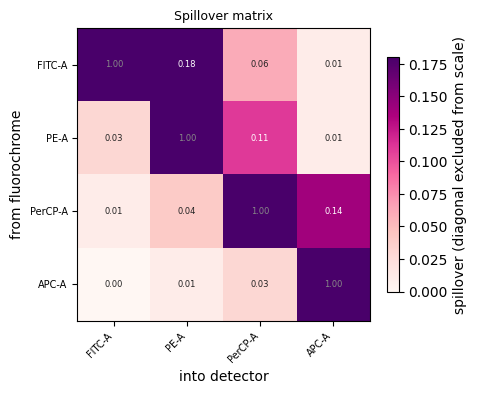

In [4]:
ov.flow.spillover_heatmap(adata)
None

## What spillover does to a plot

This is the part worth seeing rather than reading. Uncompensated, FITC (CD3)
leaking into the PE (CD4) detector produces a **diagonal smear**: every CD3+
event appears to be slightly CD4+, in exact proportion to how bright it is in
CD3. It looks exactly like a real population of double-positive cells, and it
is not one.

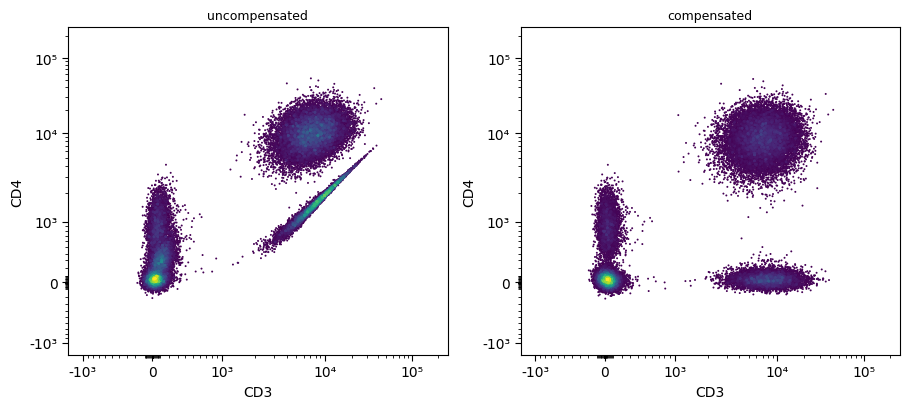

In [5]:
import matplotlib.pyplot as plt

lg = ov.flow.Logicle(t=262144.0, m=4.5, w=1.0, a=0.0)

raw = adata.copy()          # keep an uncompensated copy for the comparison
ov.flow.compensate(adata)   # uses uns['fcs']['spillover'] — the file's own matrix

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
ov.flow.biaxial(raw,   "CD3", "CD4", transforms={"CD3": lg, "CD4": lg},
                ax=axes[0], title="uncompensated", max_events=40000)
ov.flow.biaxial(adata, "CD3", "CD4", transforms={"CD3": lg, "CD4": lg},
                ax=axes[1], title="compensated", max_events=40000)
plt.tight_layout()

The smear collapses into a horizontal population sitting at zero CD4 —
which is what CD3+CD8+ T cells actually are.

The same thing as a number, on populations that are genuinely CD3-negative and
therefore cannot be CD4-bright:

In [6]:
import numpy as np

cd3_negative = adata.obs["truth"].isin(["B", "debris", "mono"]).to_numpy()
i_cd4 = list(adata.var.index).index("CD4")

print(f"CD4 median in CD3-negative populations")
print(f"  uncompensated : {np.median(raw.X[cd3_negative, i_cd4]):7.0f}")
print(f"  compensated   : {np.median(adata.X[cd3_negative, i_cd4]):7.0f}")

CD4 median in CD3-negative populations
  uncompensated :     188
  compensated   :      53


`compensate` records what it did in `uns['flow']` and keeps the
original matrix as a layer, so the operation is auditable and cannot silently
happen twice.

In [7]:
print(adata.uns["flow"]["compensated"], "|", list(adata.layers))
try:
    ov.flow.compensate(adata)
except Exception as e:
    print(f"{type(e).__name__}: {e}")

True | ['uncompensated']
ValueError: this object is already compensated. Compensating twice is silently destructive — the numbers stay plausible — so it has to be explicit: re-read the file if you meant to apply a different matrix.


## Display scales

Compensation is arithmetic; the *display scale* is what you look at. And a
compensated channel contains negative values — subtracting spillover from a dim
event routinely lands below zero, and so does the detector's own noise:

In [8]:
cd3 = adata[:, "CD3"].X.ravel()
print(f"CD3 events at or below zero: {(cd3 <= 0).sum():,} / {cd3.size:,} "
      f"({(cd3 <= 0).mean():.1%})")
print(f"minimum value: {cd3.min():.0f}")

CD3 events at or below zero: 6,784 / 59,600 (11.4%)
minimum value: -189


That single number rules out a log axis: `log10` of a negative number
does not exist, so **11% of the events would silently vanish** — including
exactly the dim events a threshold gate has to be drawn between.

A *biexponential* scale — logicle, hyperlog — is linear near zero and
logarithmic away from it, so it displays the whole range on one axis. Compare
the three on the same channel:

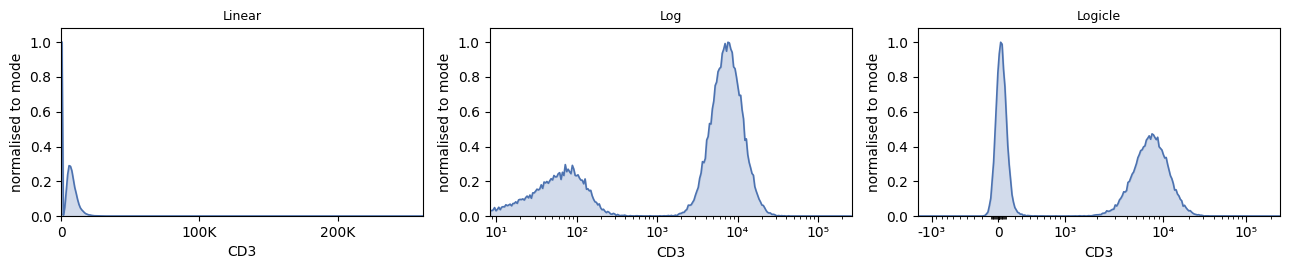

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8))
for ax, tr, name in zip(
        axes,
        [ov.flow.Linear(t=262144.0), ov.flow.Log(t=262144.0, m=4.5), lg],
        ["Linear", "Log", "Logicle"]):
    ov.flow.histogram(adata, "CD3", transforms={"CD3": tr}, ax=ax, title=name)
plt.tight_layout()

Linear crushes four decades of biology into the left edge. Log spreads
the positives out but cannot represent the negative population at all — that
peak is simply gone. Logicle keeps both.

### The `W` parameter is the whole decision

`W` sets how wide the linear region is, in decades. Too small and the negative
population is compressed into a spike at the axis edge; too large and the
positives lose resolution. It is the one logicle parameter worth tuning by
eye — which means looking at it:

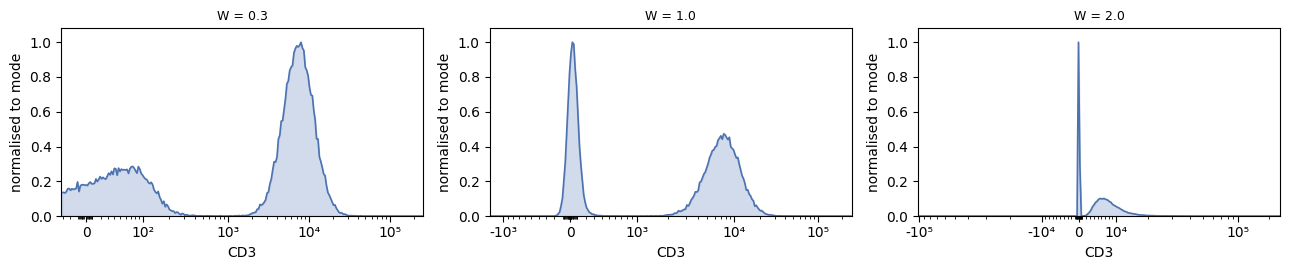

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8))
for ax, w in zip(axes, [0.3, 1.0, 2.0]):
    tr = ov.flow.Logicle(t=262144.0, m=4.5, w=w, a=0.0)
    ov.flow.histogram(adata, "CD3", transforms={"CD3": tr}, ax=ax,
                      title=f"W = {w}")
plt.tight_layout()

A transform is a serialisable object, not a function, precisely so it
can be stored next to the gate whose boundary was drawn on it:

In [11]:
lg.to_dict()

{'type': 'logicle', 't': 262144.0, 'w': 1.0, 'm': 4.5, 'a': 0.0}

## What is next

The gate is where all of this is going. A polygon drawn on a logicle axis and
the same vertices read as linear values describe completely different
populations — so in [the next notebook](t_flow_02_gating.ipynb) every gate
carries the transform it was drawn on.